## THE INTENT IS TO EXPLORE HOW ARE THE LINES PROCESSING THE GIVEN INPUT

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

### READ ONLY 40000 ROWS DUE TO LIMITED COMPUTATION CAPACITY

In [2]:
%%time
df1=pd.read_csv("sub_category.csv",nrows=40000)

CPU times: user 11.8 s, sys: 1.19 s, total: 12.9 s
Wall time: 13.1 s


In [3]:
df1.drop(columns=['Unnamed: 0'], axis=1,inplace=True)

In [4]:
df1.set_index("Id",inplace=True)

In [5]:
df1.head()

,L0_S1_F25,L0_S1_F27,L0_S1_F29,L0_S1_F31,L0_S2_F33,L0_S2_F35,L0_S2_F37,L0_S2_F39,L0_S2_F41,L0_S2_F43,...,L3_S49_F4225,L3_S49_F4227,L3_S49_F4229,L3_S49_F4230,L3_S49_F4232,L3_S49_F4234,L3_S49_F4235,L3_S49_F4237,L3_S49_F4239,L3_S49_F4240
Id,,,,,,,,,,,,,,,,,,,,,
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### FILL THE NAN TO ZERO

In [6]:
%%time
df1=df1.fillna(0)

CPU times: user 6.08 s, sys: 416 ms, total: 6.5 s
Wall time: 5.16 s


### DELETE THE DUPLICATE ROWS AS THE ONLY INTENT IS TO SEE WHAT IS BEING PROCESSED AND NOT HOW MUCH IT IS BEING PROCESSED.

In [7]:
%%time
df1new=df1.drop_duplicates(keep="first")

CPU times: user 1.94 s, sys: 188 ms, total: 2.13 s
Wall time: 2.13 s


### BELOW FUNCTION CALCULATES THE TOTAL NUMBER OF UNIQUE COMPONENTS EACH LINE IS PROCESSING.

In [8]:
def componentsCalculator(dataframe):
    components=set()
    for each in dataframe.columns:
        components.update(dataframe[each].unique())
        components.remove(0)
    return components

### CALLING THE FUNCTION FOR EACH LINE FEATURES

In [9]:
df1new_l0=df1new[[each for each in df1new.columns if "L0" in each]]
df1new_l1=df1new[[each for each in df1new.columns if "L1" in each]]
df1new_l2=df1new[[each for each in df1new.columns if "L2" in each]]
df1new_l3=df1new[[each for each in df1new.columns if "L3" in each]]

### COMBINING ALL THE COMPONENTS TO GET THE TOTAL NUMBER OF UNIQUE COMPONENTS BEING PROCESSED

In [10]:
totalComponents=componentsCalculator(df1new)
l0_components=componentsCalculator(df1new_l0)
l1_components=componentsCalculator(df1new_l1)
l2_components=componentsCalculator(df1new_l2)
l3_components=componentsCalculator(df1new_l3)

In [11]:
totalComponents
## AS WE SEE WE ARE PROCESSING SOMETHING THAT ARE NAMED AS T1,T2,ETC AND THE 
## TOTAL UNIQUE COMPONENTS ARE 43.

{'T-2147481664',
 'T-21474819',
 'T-2147482432',
 'T-2147482688',
 'T-2147482816',
 'T-2147483648',
 'T-21474872',
 'T1',
 'T128',
 'T1310',
 'T1372',
 'T143',
 'T145',
 'T16',
 'T16777216',
 'T16777232',
 'T16777248',
 'T16777557',
 'T2',
 'T24',
 'T256',
 'T262144',
 'T3',
 'T32',
 'T32896',
 'T4',
 'T48',
 'T48576',
 'T5',
 'T512',
 'T524288',
 'T6',
 'T64',
 'T6553',
 'T65536',
 'T7',
 'T786432',
 'T8',
 'T83888',
 'T9',
 'T96',
 'T97',
 'T98'}

In [12]:
l0_components

{'T1',
 'T1372',
 'T16',
 'T16777232',
 'T16777248',
 'T16777557',
 'T2',
 'T32',
 'T4',
 'T48',
 'T48576',
 'T512',
 'T64',
 'T6553',
 'T8',
 'T9',
 'T96',
 'T97',
 'T98'}

In [13]:
l1_components

{'T1',
 'T1372',
 'T16777216',
 'T2',
 'T24',
 'T262144',
 'T3',
 'T4',
 'T5',
 'T524288',
 'T6',
 'T7',
 'T786432',
 'T8',
 'T83888'}

In [14]:
l2_components

{'T1', 'T143', 'T145', 'T2'}

In [15]:
l3_components

{'T-2147481664',
 'T-21474819',
 'T-2147482432',
 'T-2147482688',
 'T-2147482816',
 'T-2147483648',
 'T-21474872',
 'T1',
 'T128',
 'T1310',
 'T16',
 'T2',
 'T256',
 'T3',
 'T32',
 'T32896',
 'T4',
 'T48',
 'T512',
 'T65536',
 'T8'}

### HAVING SEEN WHAT ARE WE PROCESSING, IT WILL BE INTERESTING TO SEE IF THESE UNIQUE ELEMENTS ARE BEING PROCESSED ON ONE LINE OR MULTIPLE LINES.


### WHAT WE WILL DO IS CREATE A NEW DATAFRAME THAT HAS ALL THE ELEMENTS AND WHAT LINE IT IS PASSING THROUGH. THE COUNT OF IT CAN BE PLOTTED.

In [16]:
dictt={}
for each in totalComponents:
    a=0
    b=0
    c=0
    d=0
    if each in l0_components:
        a=1
    if each in l1_components:
        b=1
    if each in l2_components:
        c=1
    if each in l3_components:
        d=1
    dictt[each]=(a,b,c,d)

In [17]:
dfComp=pd.DataFrame(dictt,index=["Line-0","Line-1","Line-2","Line-3"]).transpose()
dfComp["Lines"]=dfComp["Line-0"]+dfComp["Line-1"]+dfComp["Line-2"]+dfComp["Line-3"]

In [18]:
dfComp["details"]=np.nan
for each in dfComp.index:
    lis=""
    if dfComp["Line-0"].loc[each]==1:
        lis+="Line-0,"
    if dfComp["Line-1"].loc[each]==1:
        lis+="Line-1,"
    if dfComp["Line-2"].loc[each]==1:
        lis+="Line-2,"
    if dfComp["Line-3"].loc[each]==1:
        lis+="Line-3,"
    dfComp["details"].loc[each]=lis

In [19]:
dfComp=dfComp.sort_values(by=["Lines","details"])

### PLOT AS BELOW. IT SHOWS THAT MAJORITY OF ELEMENTS ARE PASSING THROUGH EACH LINE WHILE ONLY 2 ELEMENTS ARE BEING PROCESSED AT ALL TH E 4 LINES.

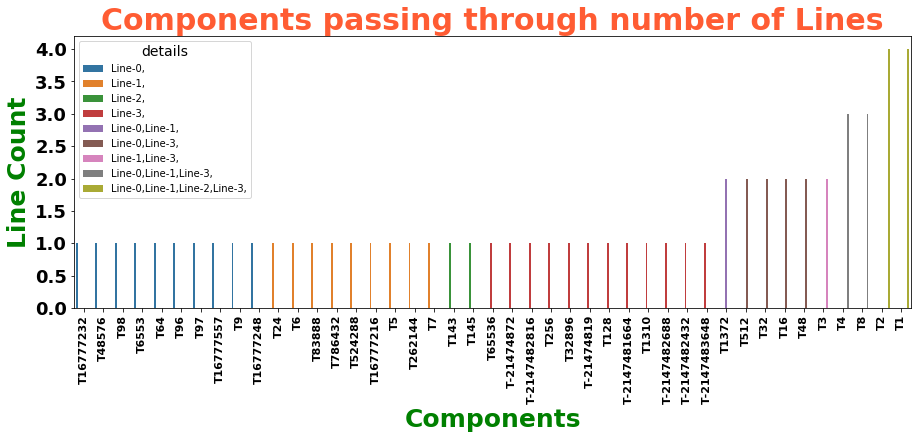

In [20]:
plot=sns.barplot(data=dfComp,x=dfComp.index,y="Lines",hue="details")
plt.gcf().set_size_inches(15,5)
plt.xlabel("Components",fontsize=25,fontweight="bold",color="green")
plt.ylabel("Line Count",fontsize=25,fontweight="bold",color="green")
plt.xticks(fontsize=11,fontweight="bold",rotation=90)
plt.yticks(fontsize=18,fontweight="bold")
plt.title("Components passing through number of Lines",
          fontsize=30,fontweight="bold",color="#ff5c33")
plt.setp(plot.get_legend().get_texts(),fontsize=10)
plt.setp(plot.get_legend().get_title(),fontsize=14)
plt.show()

### DATAFRAME THAT IS PLOTTED ABOVE

In [21]:
dfComp

,Line-0,Line-1,Line-2,Line-3,Lines,details
T16777232,1,0,0,0,1,"Line-0,"
T48576,1,0,0,0,1,"Line-0,"
T98,1,0,0,0,1,"Line-0,"
T6553,1,0,0,0,1,"Line-0,"
T64,1,0,0,0,1,"Line-0,"
T96,1,0,0,0,1,"Line-0,"
T97,1,0,0,0,1,"Line-0,"
T16777557,1,0,0,0,1,"Line-0,"
T9,1,0,0,0,1,"Line-0,"
T16777248,1,0,0,0,1,"Line-0,"
